<figure>
  <IMG SRC="gfx/Logo_norsk_pos.png" WIDTH=100 ALIGN="right">
</figure>

# H&uuml;ckel Method
*Roberto Di Remigio*, *Luca Frediani*

With the [H&uuml;ckel method] we aim at calculating the energy levels of conjugated $\pi$ systems.
The method is limited to planar, conjugated hydrocarbons and includes only the $\pi$ electrons in the system in the quantum mechanical treatment. The $\sigma$ electrons are ignored, as they are at much lower energies and will not affect molecular properties significantly.
The molecular orbitals (MOs) are built as a linear combination of atomic orbitals (LCAO),
where the atomic orbitals (AOs) in question are the $p_z$ orbitals on each of the carbon atoms.

[H&uuml;ckel method]: https://en.wikipedia.org/wiki/H%C3%BCckel_method


## Variation principle and secular equations

If $N$ is the number of carbon atoms in the conjugated hydrocarbon, the trial wavefunction is thus written as:
\begin{equation}
\Psi = \sum_{i=1}^{N}c_i\chi_i
\end{equation}
where the index $i$ runs over carbon atoms and $\chi_i$ is the $p_z$ orbital on the $i$-th atom in the molecule.
The energy, i.e. the expectation value of the many-electron Hamiltonian, is:
\begin{equation}
E(\mathbf{c}^\dagger, \mathbf{c}) = \frac{\langle \Psi | H | \Psi \rangle}{\langle \Psi | \Psi \rangle}
= \frac{\sum_{i,j=1}^{N} c_i^*H_{ij}c_j }{\sum_{i, j=1}^{N}c_i^*S_{ij}c_j}
= \frac{\mathbf{c}^\dagger\mathbf{H}\mathbf{c}}{\mathbf{c}^\dagger\mathbf{S}\mathbf{c}}
\end{equation}
where the Hamiltonian and overlap matrices were introduced:
\begin{alignat}{2}
H_{ij} = \langle \chi_i | H |\chi_j\rangle \quad& S_{ij} = \langle \chi_i | \chi_j \rangle
\end{alignat}
The variation principle guarantees that minimization of the energy function will lead to the optimal value of the coefficients, in the chosen LCAO basis.
This reduces to the generalized eigenvalue problem:
\begin{equation}
\mathbf{H}\mathbf{c} = \mathbf{S}\mathbf{c}E
\end{equation}
where the **eigenvector** $\mathbf{c}$ is the set of coefficients in the linear combination describing the MO with energy **eigenvalue** $E$.
Finding the eigenvalues can be achieved by calculating the determinant of $\mathbf{H} - E\mathbf{S}$ and setting it to zero:
\begin{equation}
\det(\mathbf{H} - E\mathbf{S}) = 0
\end{equation}

## The eigenvalue problem in H&uuml;ckel method

As already mentions, the molecular orbitals (MOs) are built as a linear combination of atomic orbitals (LCAO),
where the atomic orbitals (AOs) in question are the $p_z$ orbitals on each of the carbon atoms.
A schematic view of the model is given in the Figure below.

<figure>
  <IMG SRC="gfx/huckel.png">
</figure>

The Hamiltonian and overlap matrices are constructed from a simple set of rules:

* all overlap integrals between distinct orbitals are zero:
\begin{equation}
S_{ii} = 1 \quad S_{ij} = 0 \,\,\,\text{for}\, i\neq j
\end{equation}
* all diagonal Hamiltonian matrix elements are equal:
\begin{equation}
H_{ii} = \alpha \,\,\,\forall i
\end{equation}
where $\alpha$ is a parameter of the model. It is usually set to the energy of an isolated electron in a $2p_z$ orbital. $\alpha$ is thus a **negative number**.
* all off-diagonal Hamiltonian matrix elements are equal. They are nonzero for **adjacent** carbon atoms and zero otherwise:
\begin{equation}
H_{i, i+1} = \beta \quad H_{i, i+n} = 0 \,\,\,\text{for}\,n\geq 2
\end{equation}
where $\beta$ is a **negative** parameter that can be determined from experiment ($\beta = -75 \,\mathrm{kJ}\cdot\mathrm{mol}^{-1}$)

Once the connectivity and the values of the $\alpha$ and $\beta$ parameters are known one can set up the H&uuml;ckel matrix and the correspoding secular problem.

### A simple case: ethene

Ethene has two carbon atoms. The H&uuml;ckel matrix is:
\begin{equation}
\begin{pmatrix}
\alpha & \beta \\
\beta  & \alpha
\end{pmatrix}
\end{equation}
and its secular problem:
\begin{equation}
\det \begin{pmatrix}
(\alpha - E) & \beta \\
\beta  & (\alpha - E)
\end{pmatrix}
= (\alpha - E)^2 - \beta^2 = 0
\end{equation}
The solution of the second order equation gives the energies for the highest occupied molecular orbital $E_-$ (HOMO) and the lowest unoccupied molecular orbital $E_+$ (LUMO):
\begin{equation}
E_- = \alpha -\beta \quad E_+ = \alpha + \beta
\end{equation}
Inserting these energies in the eigenvalue equation will lead to two different systems of equations whose solution determines the coefficient in the MOs linear combinations.
Notice that the coefficients are determined up to normalization, meaning that only by imposing a normalization condition the solution to the eigenvalue problem will be unique.

## Exercise: a small script for H&uuml;ckel method

Write a Python function to calculate eigenvalues and eigenvectors for the H&uuml;ckel matrix of a generic conjugated hydrocarbon. 
The function should take four parameters:
* the number of carbon atoms in the hydrocarbon
* the value of the $\alpha$ parameter
* the value of the $\beta$ parameter
* an array specifying the connectivity of the carbon atoms

The connectivity array describes which carbon atoms are connected _via_ a double bond. This is essential, since it determines which entries in the H&uuml;ckel matrix are nonzero!
As an example, for the ethene molecule $[1, 2]$ would be the connectivity array. For the butadiene molecule one would instead have $[1, 2, 2, 3, 3, 4]$ which means that atom $1$ is connected to atom $2$ by a double bond, atom $2$ and $3$ are connected by a single bond and atom $3$ and $4$ are again connected by a double bond.
Why so? Because butadiene has 4 carbon atoms, hence only two double bonds can be present. Since these have to be _alternating_ carbon $2$ and carbon $3$ must be connected by a single bond.
To help with determining the connectivity array, draw the molecule and number all carbon atoms.
The function will, of course, use NumPy for manipulating matrices and vectors.
The module `linalg` includes the functions necessary for linear algebra manipulations. In our case, we're interested in finding eigenvalues and eigenvectors of the H&uuml;ckel matrix with the [`eig` function]

```Python
def huckel(n, alpha, beta, connectivity):
    """ Huckel method
    
    n -- number of carbon atoms
    alpha -- Coulomb integral
    beta --  resonance integral
    connectivity -- an array of integers defining the connectivity
    """
    import numpy as np
    from numpy import linalg as LA
    
    H = np.zeros((n, n))
    # Fill the matrix!
    ## Fill diagonal
    
    ## Fill off-diagonal
    
    # Print H
    print('Huckel matrix is {}'.format(H))
    
    # Diagonalize H
    energies, orbitals = LA.eig(H)
    # Sort eigenvalues and eigenvectors in ascending order
    sort_perm = energies.argsort()
    energies.sort()     # <-- This sorts the list in place.
    orbitals = evecs[:, sort_perm]
    
    # Return energies and orbitals
    return energies, orbitals
```

[`eig` function]: http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html#numpy.linalg.eig

In [10]:
def huckel(n, alpha, beta, connectivity):
    """ Huckel method
    
    n -- number of carbon atoms
    alpha -- Coulomb integral
    beta --  resonance integral
    connectivity -- an array of integers defining the connectivity
    """
    import numpy as np
    from numpy import linalg as LA
    
    H = np.zeros((n, n))
    # Fill the matrix!
    ## Fill diagonal
    
    ## Fill off-diagonal
    
    # Print H
    print('Huckel matrix is \n{}'.format(H))
    
    # Diagonalize H
    energies, evecs = LA.eig(H)
    # Sort eigenvalues and eigenvectors in ascending order:q
    sort_perm = energies.argsort()
    energies.sort()     # <-- This sorts the list in place.
    orbitals = evecs[:, sort_perm]
    
    # Return energies and orbitals
    return energies, orbitals

energies, orbitals = huckel(4, -5.0, -75.0, [1, 2, 2, 3, 3, 4])
print('Huckel model energies \n{}'.format(energies))
print('Huckel model orbitals \n{}'.format(orbitals))

Huckel matrix is 
[[ -5. -75.   0.   0.]
 [-75.  -5. -75.   0.]
 [  0. -75.  -5. -75.]
 [  0.   0. -75.  -5.]] 

Huckel model energies 
[-126.35254916  -51.35254916   41.35254916  116.35254916]
Huckel model orbitals 
[[ 0.37174803 -0.60150096  0.60150096 -0.37174803]
 [ 0.60150096 -0.37174803 -0.37174803  0.60150096]
 [ 0.60150096  0.37174803 -0.37174803 -0.60150096]
 [ 0.37174803  0.60150096  0.60150096  0.37174803]]


## Visualizing the molecular orbitals

Use computed MO coefficients to visualize the MOs. 

Make simple plots of *atom_index* vs *MO coefficient*.

Use the function below to visualize with spheres of "atoms".

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mos(orbitals, energies, positions, cyclic=False):
    N_atoms, N_MOs = orbitals.shape
    x, y = positions[:,0], positions[:,1]

    for i in range(N_MOs):
        coeffs = np.array(orbitals[:, i]).flatten()
        sizes = 2000 * np.abs(coeffs)

        plt.figure(figsize=(5,5))
        plt.scatter(x, y, s=sizes.astype(float), c=np.sign(coeffs), cmap="bwr", vmin=-1, vmax=1)

        # Draw bonds
        for j in range(N_atoms-1):
            plt.plot([x[j], x[j+1]], [y[j], y[j+1]], "k-", lw=2)
        if cyclic:
            plt.plot([x[-1], x[0]], [y[-1], y[0]], "k-", lw=2)

        # label coefficients
        for xi, yi, ci in zip(x, y, coeffs):
            plt.text(xi, yi + 0.05, f"{ci:+.2f}", ha="center", va="bottom", fontsize=10)

        plt.axis("equal")
        plt.axis("off")
        plt.title(f"MO {i+1}, Energy = {energies[i]:.2f}")
        plt.show()

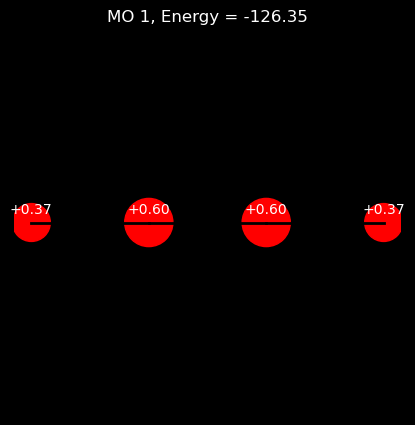

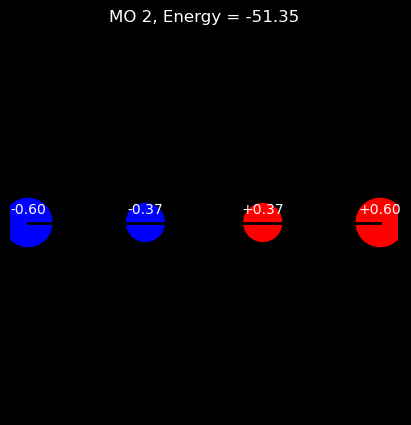

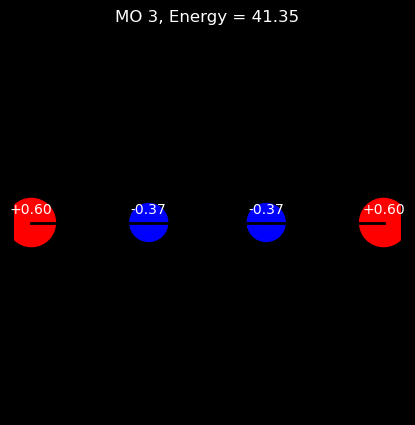

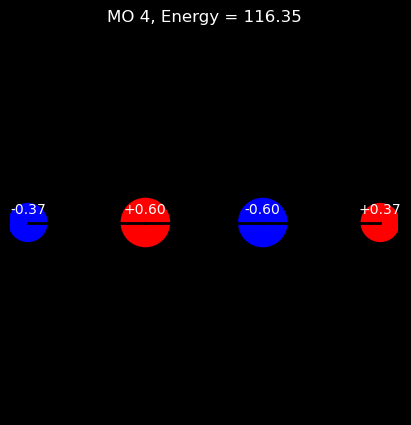

In [11]:
# example: linear chain - butadiene
N = 4
positions_linear = np.column_stack([np.arange(N), np.zeros(N)])
plot_mos(orbitals, energies, positions_linear, cyclic=False)

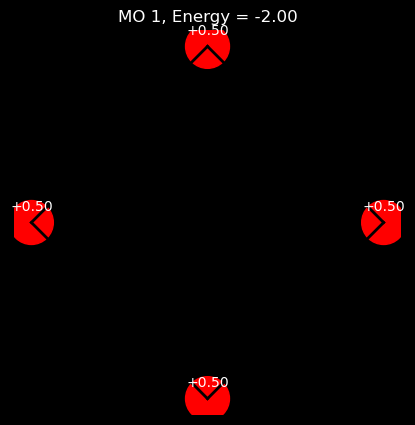

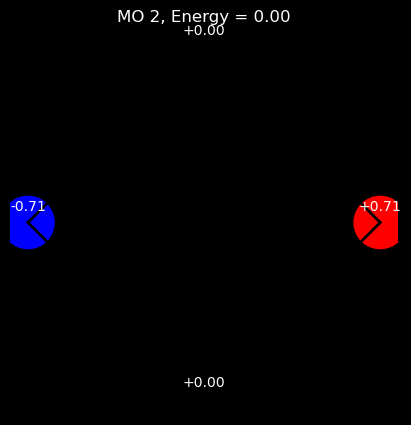

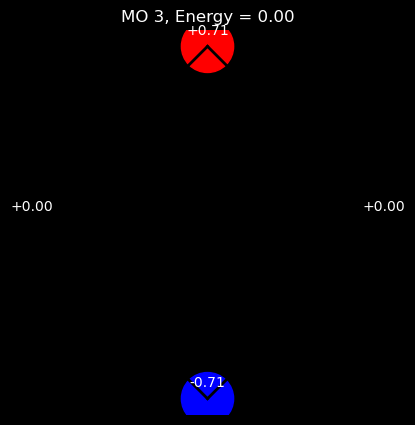

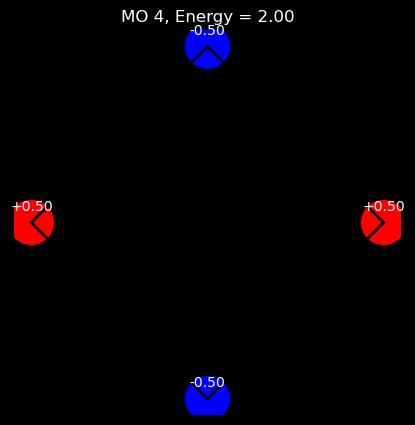

In [ ]:
# cyclic molecule example: now reusing orbitals of butadiene, should use orbitals of cyclobutadiene here
N = 4
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
x = np.cos(theta)
y = np.sin(theta)
positions_cyclic = np.column_stack((x, y))  # shape (N,2)

plot_mos(orbitals_cb, energies_cb, positions_cyclic, cyclic=True)